In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset Loading

In [6]:
data = pd.read_excel("Amazon_Original_DataSet_For_Coolab.xlsx")

In [8]:
# Q1. Load the Amazon_Sales.xlsx dataset into a Pandas DataFrame and display the first five records.
data.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


# Dataset Overview

In [9]:
# •	Number of rows and columns
data.shape

(100000, 20)

In [10]:
# •	Column names
data.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [11]:
# •	Data types
data.dtypes

,0
OrderID,object
OrderDate,datetime64[ns]
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64


In [12]:
# •	Statistical summary of numerical columns
data.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [13]:
# •	Statistical summary of numerical columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

# KPI Analysis

In [14]:
# •	Total Sales
data.TotalAmount.sum()

np.float64(91825647.92)

In [15]:
# •	Total Profit
# Formula of Profit = Selling Price (S.P.) - Cost Price (C.P.)
# but there is not given Cost of Product

In [16]:
# •	Total Orders
data.OrderID.count()

np.int64(100000)

In [17]:
# •	Average Sales
data.TotalAmount.mean()

np.float64(918.2564792000001)

In [18]:
# •	Average Profit
# Profit not given

In [19]:
# •	Maximum Sales
data.TotalAmount.max()

3534.98

In [20]:
# •	Minimum Sales
data.TotalAmount.min()

4.27

# Sales Analysis

In [21]:
# Q4. Find the total sales generated by each State and display the results in descending order.

data.groupby("State")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [22]:
# Q5. Find the total sales generated by each Category.
data.groupby("Category")["TotalAmount"].sum()

,TotalAmount
Category,
Books,15261837.01
Clothing,15253397.50
Electronics,15584217.18
Home & Kitchen,15163939.36
Sports & Outdoors,15345571.88
Toys & Games,15216684.99


In [23]:
# Q6. Find the total sales generated by each Sub-Category.
data.groupby("ProductName")["TotalAmount"].sum()

,TotalAmount
ProductName,
4K Monitor,1866774.35
Action Camera,1829029.24
Air Fryer,1789927.34
Backpack,1749971.14
Bluetooth Speaker,1803356.76
Board Game,1863310.96
Car Charger,1779795.27
Children's Book,1738112.57
Cookware Set,1877038.73


# Customer & Product Analysis

In [24]:
# Q7. Display the Top 5 Customers based on total sales.
data.groupby("CustomerName")["TotalAmount"].sum().sort_values(ascending=False).head()

,TotalAmount
CustomerName,
Pooja Kapoor,547832.64
Vihaan Singh,526675.89
Pooja Singh,516451.45
Kabir Joshi,515361.68
Aditya Gupta,515005.09


In [25]:
# Q8. Find the total quantity sold for each product.
data.groupby("ProductName")["Quantity"].count()

,Quantity
ProductName,
4K Monitor,2006
Action Camera,2024
Air Fryer,2007
Backpack,1910
Bluetooth Speaker,1913
Board Game,2039
Car Charger,1917
Children's Book,1914
Cookware Set,2058


# Payment Analysis

In [26]:
# Q9. Find the number of orders placed using each Payment Mode.
data.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False)

,OrderID
PaymentMethod,
Credit Card,35038
Debit Card,20024
UPI,15066
Amazon Pay,15017
Net Banking,9927
Cash on Delivery,4928


#Time-based Analysis

In [27]:
# Q10. Calculate the monthly sales trend using the Order Date column.
data["month_number"]= data.OrderDate.dt.month
data["month_name"]= data.OrderDate.dt.month_name()

# we group by Month-name in Ascending Order
data.groupby(["month_number","month_name"])["TotalAmount"].sum()

,,TotalAmount
month_number,month_name,
1,January,7883801.27
2,February,6931724.49
3,March,7766527.73
4,April,7646203.22
5,May,7864283.27
6,June,7654636.75
7,July,7737925.51
8,August,7890598.37
9,September,7558970.85


# Multi-level Analysis

In [28]:
# Q11. Find the sales generated by each State for every Category.

data.groupby(["State","Category"])["TotalAmount"].sum()

State  Category         
AZ     Books                793211.33
       Clothing             691249.82
       Electronics          747955.37
       Home & Kitchen       737616.34
       Sports & Outdoors    694318.06
                              ...    
WA     Clothing             747668.70
       Electronics          879580.90
       Home & Kitchen       809448.28
       Sports & Outdoors    807282.60
       Toys & Games         711514.12
Name: TotalAmount, Length: 78, dtype: float64

# Visualization

In [ ]:
# Q12. Create a Bar Chart showing Sales by State.

State = data.State
Sales = data.TotalAmount
bar = plt.bar(State,Sales)
plt.title("Sales by States")

plt.show()

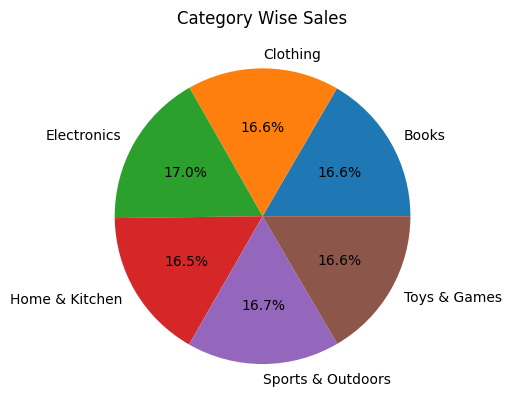

In [30]:
# Q13. Create a Pie Chart showing Category-wise Sales.
Sales = data.groupby("Category")["TotalAmount"].sum()

plt.pie(Sales,labels=Sales.index,autopct="%1.1f%%")
plt.title("Category Wise Sales")
plt.show()



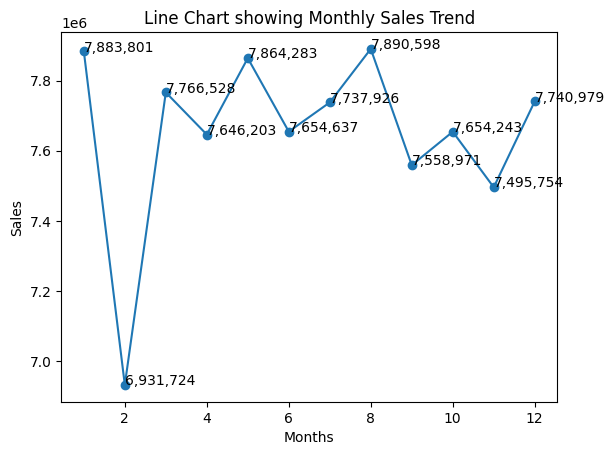

In [39]:
# Q14. Create a Line Chart showing Monthly Sales Trend.
sales = data.groupby("month_number")["TotalAmount"].sum()
months = sales.index
total_sales = sales.values
val = plt.plot(months,total_sales,marker = "o")
for x,y in zip(months,sales):
  plt.text(x,y,f'{y:,.0f}')
plt.title("Line Chart showing Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

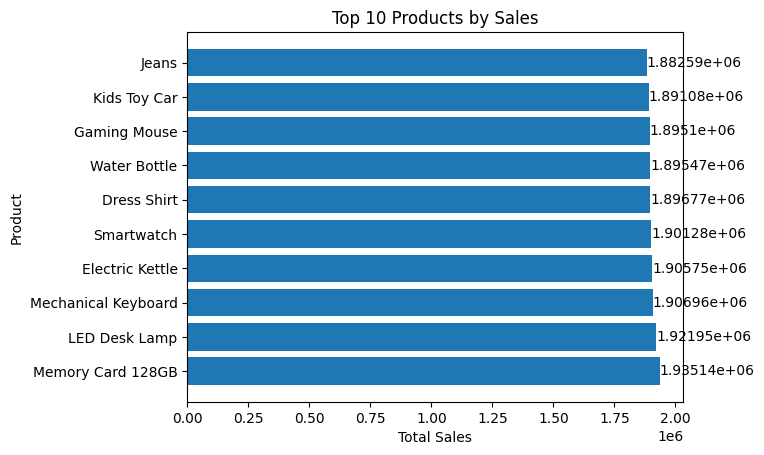

In [37]:
# Q15. Create a Horizontal Bar Chart showing the Top 10 Products by Sales.

top_ten_products = data.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10)

products = top_ten_products.index
amount = top_ten_products.values
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.title("Top 10 Products by Sales")
bar = plt.barh(products,amount)
plt.bar_label(bar)
plt.show()